## 1. Evaluate different ML models on the same subset of features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sksurv.util import Surv
from sksurv.metrics import cumulative_dynamic_auc, concordance_index_censored, concordance_index_ipcw
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, ComponentwiseGradientBoostingSurvivalAnalysis, GradientBoostingSurvivalAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import joblib

In [2]:
print(plt.rcParams["font.family"])
plt.rcParams["font.sans-serif"] = ["Arial"] + plt.rcParams["font.sans-serif"]

['sans-serif']


In [3]:
# Load formatted cytokines data
df = pd.read_csv("../data/CV_plasma_Combined_formatted_20260731.csv")
df = df.loc[df["cohort"] == "UAB"]

In [4]:
# Encode survival status as binary variable
df["survival_status_encoded"] = df["survival_status"].map({"alive": 0, "death": 1})

In [5]:
# Map string labels to boolean: True = death observed, False = alive
event_observed = df["survival_status"].map(
    {"death": True, "alive": False}
)

# Check for NA values in survival_status mapping
assert event_observed.isna().sum() == 0, (
    f"Unmapped survival_status values found: "
    f"{df['survival_status'][event_observed.isna()].unique()}"
)

# Create structured array for survival analysis
y = Surv.from_arrays(
        event=event_observed,
        time=df["sx_to_lastfu"]
    )

y

array([(False, 1521.), (False, 1594.), (False, 1629.), ( True,  761.),
       (False, 1681.), (False, 1646.), (False, 1618.), (False, 1420.),
       (False, 1091.), ( True,  365.), (False, 1532.), ( True,  273.),
       (False, 1267.), (False, 1235.), (False, 1049.), ( True,   61.),
       ( True,   61.), (False, 1382.), (False, 1421.), ( True, 1066.),
       (False, 1294.), (False, 1370.), ( True,  306.), (False, 1197.),
       (False, 1196.), ( True,  334.), (False, 1291.), ( True,  762.),
       (False,  425.), (False, 1099.), ( True,  761.), (False, 1077.),
       ( True,  761.), ( True,  792.), (False, 1917.), (False, 1770.),
       ( True, 1064.), (False, 1714.), (False, 1770.), (False, 1841.),
       (False,  357.), ( True,  426.), ( True,  242.), (False, 1807.),
       (False, 1461.), ( True,  424.), (False,  389.), ( True,  577.),
       (False, 1664.), (False, 1712.), (False, 1623.), (False, 1697.),
       (False, 1476.), (False, 1460.), (False, 1721.), ( True,  184.),
      

In [6]:
# Specify lists of variables for analysis
clinicopathologic_vars = [
    "ages", "sex", "race", "tobaccouse", "alcoholuse",
    "pathologicstage", "lvi", "pni",
    "survival_status", "sx_to_lastfu", "survival_2yrs"
]
pain_scores = [
    "averageucsf", "spontaneouspain135", "functionalpain246", "bpiphysicalinterferences",
    "bpipsychologicalinterferences", "bpi_intensity", "functionalscores", "symptomscore",
    "globalhealthstatusql2", "qlq30score", "hn35"
]
cytokines = [
    "egf", "ifnalpha2",	"ifngamma",	"il1alpha",
    "il1beta", "il4", "il6", "il8",	"il10",
    "mip1alpha", "tgfalpha", "tnfalpha", "tnfbeta",
    "hbegf", "vegfc", "vegfd"
]

In [7]:
# Subset cytokines and cohort columns for analysis
cytokines_uab_df = df.loc[:, cytokines + ["cohort", "ss", "survival_status_encoded"]]
cytokines_uab_df

,egf,ifnalpha2,ifngamma,il1alpha,il1beta,il4,il6,il8,il10,mip1alpha,tgfalpha,tnfalpha,tnfbeta,hbegf,vegfc,vegfd,cohort,ss,survival_status_encoded
112,16.13,71.75,30.12,20.41,2.20,75.53,4.71,7.41,26.83,9.79,NaN,8.44,15.26,NaN,230.18,60.78,UAB,3,0
113,45.21,77.65,30.12,21.55,2.49,122.72,6.73,8.74,11.17,13.73,NaN,12.27,22.85,NaN,319.22,81.83,UAB,3,0
114,47.15,93.24,67.08,307.71,7.73,3483.00,149.54,163.45,91.61,12.80,NaN,13.65,664.85,NaN,462.03,53.98,UAB,1,0
115,16.38,91.86,42.43,12.93,3.59,32.65,3.00,5.34,12.03,8.72,NaN,15.85,7.46,NaN,78.37,49.29,UAB,4,1
116,13.78,76.19,34.67,10.35,4.89,29.29,4.57,11.16,9.66,7.57,NaN,27.83,10.54,NaN,339.91,75.53,UAB,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,61.90,122.36,103.74,552.31,15.62,5864.00,199.75,208.34,168.84,18.23,NaN,19.66,855.53,NaN,289.94,91.56,UAB,3,1
208,18.86,91.86,71.49,22.67,5.42,146.71,18.96,12.67,82.12,10.90,NaN,26.21,19.05,NaN,234.20,65.32,UAB,1,0
209,12.99,66.46,51.61,9.46,2.89,28.61,2.28,8.89,7.41,9.54,NaN,13.77,7.24,NaN,144.61,55.09,UAB,4,0
210,13.66,75.02,40.79,8.96,3.81,38.38,5.04,4.50,12.45,6.71,NaN,16.65,11.06,NaN,158.81,21.47,UAB,2,0


In [8]:
# Specify numeric features for ML models
numeric_features = cytokines_uab_df.columns.drop(["cohort", "survival_status_encoded"])

In [34]:
# Subset model
selected_features = numeric_features.intersection(["il6", "il8", "il10", "tnfalpha", "ss"])
print(f"Selected features for ML model: {selected_features}")

# `selected_features` is a pandas Index; convert to list before adding "cohort"
feature_cols = selected_features.tolist() + ["cohort"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    cytokines_uab_df[feature_cols],
    y,
    test_size=0.2,
    random_state=2024,
    stratify=y["event"],
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Selected features for ML model: Index(['il6', 'il8', 'il10', 'tnfalpha', 'ss'], dtype='object')
Training set size: 80 samples
Test set size: 20 samples


In [35]:
# Preprcessing
# Fit one scaler per cohort on the training set, store them explicitly
cohort_scalers = {}
for cohort, group in X_train.groupby("cohort"):
    sc = StandardScaler()
    sc.fit(group[selected_features])
    cohort_scalers[cohort] = sc

def apply_cohort_scaling(X, scalers, feature_cols):
    parts = []
    for cohort, group in X.groupby("cohort"):
        transformed = scalers[cohort].transform(group[feature_cols])
        parts.append(pd.DataFrame(transformed, columns=feature_cols, index=group.index))
    return pd.concat(parts).loc[X.index]

X_train_transformed = apply_cohort_scaling(X_train, cohort_scalers, selected_features)
X_test_transformed = apply_cohort_scaling(X_test, cohort_scalers, selected_features)

In [36]:
X_train

,il6,il8,il10,tnfalpha,ss,cohort
154,0.00,2.59,7.90,9.35,3,UAB
209,2.28,8.89,7.41,13.77,4,UAB
177,36.14,51.37,37.41,17.54,4,UAB
186,2.22,7.46,13.35,14.66,4,UAB
126,3.12,11.52,13.42,21.72,0,UAB
...,...,...,...,...,...,...
187,2.19,5.31,12.03,16.38,2,UAB
198,0.00,3.21,7.74,16.97,1,UAB
211,10.83,12.75,24.33,11.46,0,UAB
185,3.18,9.87,9.26,12.15,3,UAB


In [37]:
X_train_transformed

,il6,il8,il10,tnfalpha,ss
154,-0.615001,-0.666577,-0.619247,-0.867079,0.335643
209,-0.524760,-0.421453,-0.637543,-0.225134,1.081518
177,0.815402,1.231384,0.482591,0.322407,1.081518
186,-0.527135,-0.477092,-0.415756,-0.095874,1.081518
126,-0.491513,-0.319123,-0.413143,0.929494,-1.901979
...,...,...,...,...,...
187,-0.528322,-0.560746,-0.465042,0.153932,-0.410231
198,-0.615001,-0.642454,-0.625221,0.239622,-1.156105
211,-0.186355,-0.271266,-0.005787,-0.560630,-1.901979
185,-0.489138,-0.383323,-0.568468,-0.460417,0.335643


In [38]:
# Sanity check: Ensure that the time range of the test data is within the time range of the training data
y_events = y_train[y_train["event"]]
train_min, train_max = y_events["time"].min(), y_events["time"].max()

y_events = y_test[y_test["event"]]
test_min, test_max = y_events["time"].min(), y_events["time"].max()

assert (
    train_min <= test_min < test_max < train_max
), "time range or test data is not within time range of training data."

In [39]:
# Evaluation times for time-dependent ROC (restricted to 2 years)
horizon_days = 365.24 * 2

# last time must be strictly below max follow-up
upper_time = min(
    horizon_days,
    np.nextafter(y_train["time"].max(), -np.inf),
    np.nextafter(y_test["time"].max(), -np.inf),
)

# use event-time quantiles from test set, then keep valid range
event_times_test = y_test["time"][y_test["event"]]
times = np.percentile(event_times_test, np.linspace(5, 95, 15))
times = np.unique(times[(times >= y_test["time"].min()) & (times <= upper_time)])

print(times)
print(f"Max evaluation time: {times.max():.1f} days (<= 2 years)")

[206.25       234.85714286 263.46428571 305.78571429 354.96428571
 404.14285714 450.46428571 494.5        538.53571429 595.71428571
 669.32142857]
Max evaluation time: 669.3 days (<= 2 years)


il6: mean AUC = 0.753
il8: mean AUC = 0.707
il10: mean AUC = 0.627
tnfalpha: mean AUC = 0.694
ss: mean AUC = 0.587


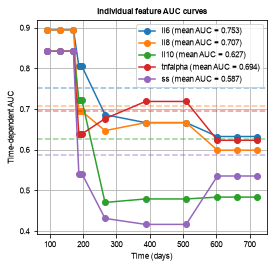

In [23]:
# Plot time-dependent AUC curves for individual features separately
plt.figure(figsize=(10.5, 10, "cm"))

X_test_arr = np.asarray(X_test_transformed)

for i, col in enumerate(selected_features):
    auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, X_test_arr[:, i], times)
    print(f"{col}: mean AUC = {mean_auc:.3f}")
    plt.plot(times, auc, marker="o", label=f"{col} (mean AUC = {mean_auc:.3f})")
    plt.axhline(mean_auc, linestyle="--", alpha=0.5, color=plt.gca().lines[-1].get_color())

plt.xlabel("Time (days)", fontsize=8)
plt.xticks(fontsize=8)
plt.ylabel("Time-dependent AUC", fontsize=8)
plt.yticks(fontsize=8)
plt.title("Individual feature AUC curves", fontsize=8, fontweight="bold")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True)

# plt.savefig("../figures/individual_feature_auc_curves.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [24]:
# CoxPH surival model
cph = CoxPHSurvivalAnalysis()
cph.fit(X_train_transformed, y_train)
c_index = cph.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

cph_risk_scores = cph.predict(X_test_transformed)
cph_auc, cph_mean_auc = cumulative_dynamic_auc(y_train, y_test, cph_risk_scores, times)
print(f"Mean AUC: {cph_mean_auc:.3f}")

C-index: 0.552
Mean AUC: 0.488


In [25]:
# Gradient-boosted CoxPH loss with regression trees as base learner
gbsa_tree = GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=2026)
gbsa_tree.fit(X_train_transformed, y_train)
c_index = gbsa_tree.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

gbsa_tree_risk_scores = gbsa_tree.predict(X_test_transformed)
gbsa_tree_auc, gbsa_tree_mean_auc = cumulative_dynamic_auc(y_train, y_test, gbsa_tree_risk_scores, times)
print(f"Mean AUC: {gbsa_tree_mean_auc:.3f}")

C-index: 0.672
Mean AUC: 0.603


In [26]:
# Gradient boosting CoxPH with component-wise least squares as base learner
gbsa_ls = ComponentwiseGradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=1.0, random_state=2026)
gbsa_ls.fit(X_train_transformed, y_train)
cindex = gbsa_ls.score(X_test_transformed, y_test)
print(f"C-index: {round(cindex, 3)}")

gbsa_ls_risk_scores = gbsa_ls.predict(X_test_transformed)
gbsa_ls_auc, gbsa_ls_mean_auc = cumulative_dynamic_auc(y_train, y_test, gbsa_ls_risk_scores, times)
print(f"Mean AUC: {gbsa_ls_mean_auc:.3f}")

C-index: 0.625
Mean AUC: 0.663


In [27]:
# Random Survival Forest (RSF) model
rsf = RandomSurvivalForest()
rsf.fit(X_train_transformed, y_train)
c_index = rsf.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

rsf_risk_scores = rsf.predict(X_test_transformed)
rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times)
print(f"Mean AUC: {rsf_mean_auc:.3f}")

C-index: 0.667
Mean AUC: 0.636


In [28]:
# Permutation-based feature importance
result = permutation_importance(rsf, X_test_transformed, y_test, n_repeats=15, random_state=2026)

pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=X_test_transformed.columns,
).sort_values(by="importances_mean", ascending=False)

,importances_mean,importances_std
ss,0.081250,0.115508
il8,0.063889,0.057291
il10,0.058333,0.029167
tnfalpha,0.039583,0.042730
il6,0.036111,0.066522


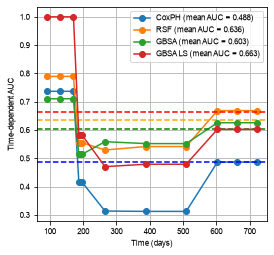

In [29]:
# Plot all models together for comparison
plt.figure(figsize=(10.5, 10, "cm"))

plt.plot(times, cph_auc, "o-", label=f"CoxPH (mean AUC = {cph_mean_auc:.3f})")
plt.axhline(cph_mean_auc, color="blue", linestyle="--",)
plt.plot(times, rsf_auc, "o-", label=f"RSF (mean AUC = {rsf_mean_auc:.3f})")
plt.axhline(rsf_mean_auc, color="orange", linestyle="--",)
plt.plot(times, gbsa_tree_auc, "o-", label=f"GBSA (mean AUC = {gbsa_tree_mean_auc:.3f})")
plt.axhline(gbsa_tree_mean_auc, color="green", linestyle="--",)
plt.plot(times, gbsa_ls_auc, "o-", label=f"GBSA LS (mean AUC = {gbsa_ls_mean_auc:.3f})")
plt.axhline(gbsa_ls_mean_auc, color="red", linestyle="--",)
plt.xlabel("Time (days)", fontsize=8)
plt.xticks(fontsize=8)
plt.ylabel("Time-dependent AUC", fontsize=8)
plt.yticks(fontsize=8)
# plt.title("Time-dependent AUC by subset model", fontsize=8, fontweight="bold")
plt.legend(loc="upper right", fontsize=8)
plt.grid(True)

# plt.savefig("../figures/time_dependent_auc_subset_model_within2yrs.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

## 2. Evaluate the RSF model on different subsets of features

In [44]:
# Define a function to run RSF on a given feature set
def run_rsf(feature_set, cols, cytokines_df, numeric_features, y, times,
            cohort_col="cohort", test_size=0.2):
    """Train/evaluate an RSF model on one feature subset. Returns a dict
    with the model, C-index, AUC curve, and mean AUC."""
    
    selected_features = numeric_features.intersection(cols).tolist()
    feature_cols = selected_features + [cohort_col]

    X_train, X_test, y_train, y_test = train_test_split(
        cytokines_df[feature_cols], y,
        test_size=test_size, random_state=2024, stratify=y["event"]
    )
    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Test set size: {X_test.shape[0]} samples")

    # Sanity check: Ensure that the time range of the test data is within the time range of the training data
    y_events = y_train[y_train["event"]]
    train_min, train_max = y_events["time"].min(), y_events["time"].max()
    
    y_events = y_test[y_test["event"]]
    test_min, test_max = y_events["time"].min(), y_events["time"].max()

    assert (
        train_min <= test_min < test_max < train_max
    ), "time range or test data is not within time range of training data."

    # Preprocessing
    # Fit one scaler per cohort on the training set, store them explicitly
    cohort_scalers = {}
    for cohort, group in X_train.groupby("cohort"):
        sc = StandardScaler()
        sc.fit(group[selected_features])
        cohort_scalers[cohort] = sc
    
    def apply_cohort_scaling(X, scalers, feature_cols):
        parts = []
        for cohort, group in X.groupby("cohort"):
            transformed = scalers[cohort].transform(group[feature_cols])
            parts.append(pd.DataFrame(transformed, columns=feature_cols, index=group.index))
        return pd.concat(parts).loc[X.index]
    
    X_train_transformed = apply_cohort_scaling(X_train, cohort_scalers, selected_features)
    X_test_transformed = apply_cohort_scaling(X_test, cohort_scalers, selected_features)

    # # Random Survival Forest (RSF) model
    rsf = RandomSurvivalForest(random_state=2026)
    rsf.fit(X_train_transformed, y_train)
    c_index = rsf.score(X_test_transformed, y_test)
    rsf_risk_scores = rsf.predict(X_test_transformed)
    rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times)

    print(f"[{feature_set}] features: {selected_features}")
    print(f"[{feature_set}] C-index: {c_index:.3f} | Mean AUC: {rsf_mean_auc:.3f}")

    return {
        "feature_set": feature_set,
        "features": selected_features,
        "model": rsf,
        "c_index": c_index,
        "auc": rsf_auc,
        "mean_auc": rsf_mean_auc
    }

In [45]:
# Define a function to run RSF on all feature sets and plot AUC curves
def run_all(feature_sets, cytokines_df, numeric_features, y, times, data_dir, fig_dir, **kwargs):
    """Run `run_rsf` for every {feature_set: cols} pair. Returns (results, summary_df)
    and plots all AUC curves together on one figure."""

    results = [
        run_rsf(feature_set, cols, cytokines_df, numeric_features, y, times, **kwargs)
        for feature_set, cols in feature_sets.items()
    ]

    summary_df = pd.DataFrame([
        {
            "feature_set": res["feature_set"], 
            "n_features": len(res["features"]),
            "features": ", ".join(res["features"]),
            "c_index": round(res["c_index"], 3),
            "mean_auc": round(res["mean_auc"], 3)
        }
        for res in results
    ]).sort_values("mean_auc", ascending=False).reset_index(drop=True)
    # summary_df.to_csv(f"{data_dir}/rsf_feature_sets_uab_summary.csv", index=False)

    # Sort results by mean_auc descending for legend ordering
    results_sorted = sorted(results, key=lambda x: x["mean_auc"], reverse=True)
    
    plt.figure(figsize=(20, 10, "cm"), dpi=300)
    for res in results_sorted:
        line, = plt.plot(
            times,
            res["auc"],
            marker="o",
            linestyle="-",
            label=f'{", ".join(res["features"])} (mean AUC = {res["mean_auc"]:.3f})',
        )
        plt.axhline(
            res["mean_auc"],
            color=line.get_color(),
            linestyle="--",
        )
    plt.xlabel("Time (days)", fontsize=8)
    plt.xticks(fontsize=8)
    plt.ylabel("Time-dependent AUC", fontsize=8)
    plt.yticks(fontsize=8)
    # plt.title("Time-dependent AUC by feature set", fontsize=8, fontweight="bold")
    plt.legend(loc="upper center", fontsize=8, bbox_to_anchor=(0.5, -0.15))
    plt.grid(True)
    
    # plt.savefig(f"{fig_dir}/time-dependent-auc_features-comparison-uab_rsf-model_within2yrs.pdf", dpi=300, bbox_inches="tight", facecolor="white")
    
    plt.show()
    
    return results, summary_df

In [46]:
# Specify feature sets for RSF model evaluation
feature_sets = {
    "set_01": ["ss"],
    "set_02": ["il6", "il8", "il10", "tnfalpha"],
    "set_03": ["ss", "il6", "il8", "il10", "tnfalpha"],
    "set_04": ["ss", "il6", "il10", "tnfalpha"],
    "set_05": ["ss", "il8", "il10", "tnfalpha"],
    "set_06": ["ss", "il10", "tnfalpha"],
}

Training set size: 80 samples
Test set size: 20 samples
[set_01] features: ['ss']
[set_01] C-index: 0.775 | Mean AUC: 0.778
Training set size: 80 samples
Test set size: 20 samples
[set_02] features: ['il6', 'il8', 'il10', 'tnfalpha']
[set_02] C-index: 0.562 | Mean AUC: 0.663
Training set size: 80 samples
Test set size: 20 samples
[set_03] features: ['il6', 'il8', 'il10', 'tnfalpha', 'ss']
[set_03] C-index: 0.708 | Mean AUC: 0.787
Training set size: 80 samples
Test set size: 20 samples
[set_04] features: ['il6', 'il10', 'tnfalpha', 'ss']
[set_04] C-index: 0.685 | Mean AUC: 0.683
Training set size: 80 samples
Test set size: 20 samples
[set_05] features: ['il8', 'il10', 'tnfalpha', 'ss']
[set_05] C-index: 0.652 | Mean AUC: 0.610
Training set size: 80 samples
Test set size: 20 samples
[set_06] features: ['il10', 'tnfalpha', 'ss']
[set_06] C-index: 0.764 | Mean AUC: 0.704


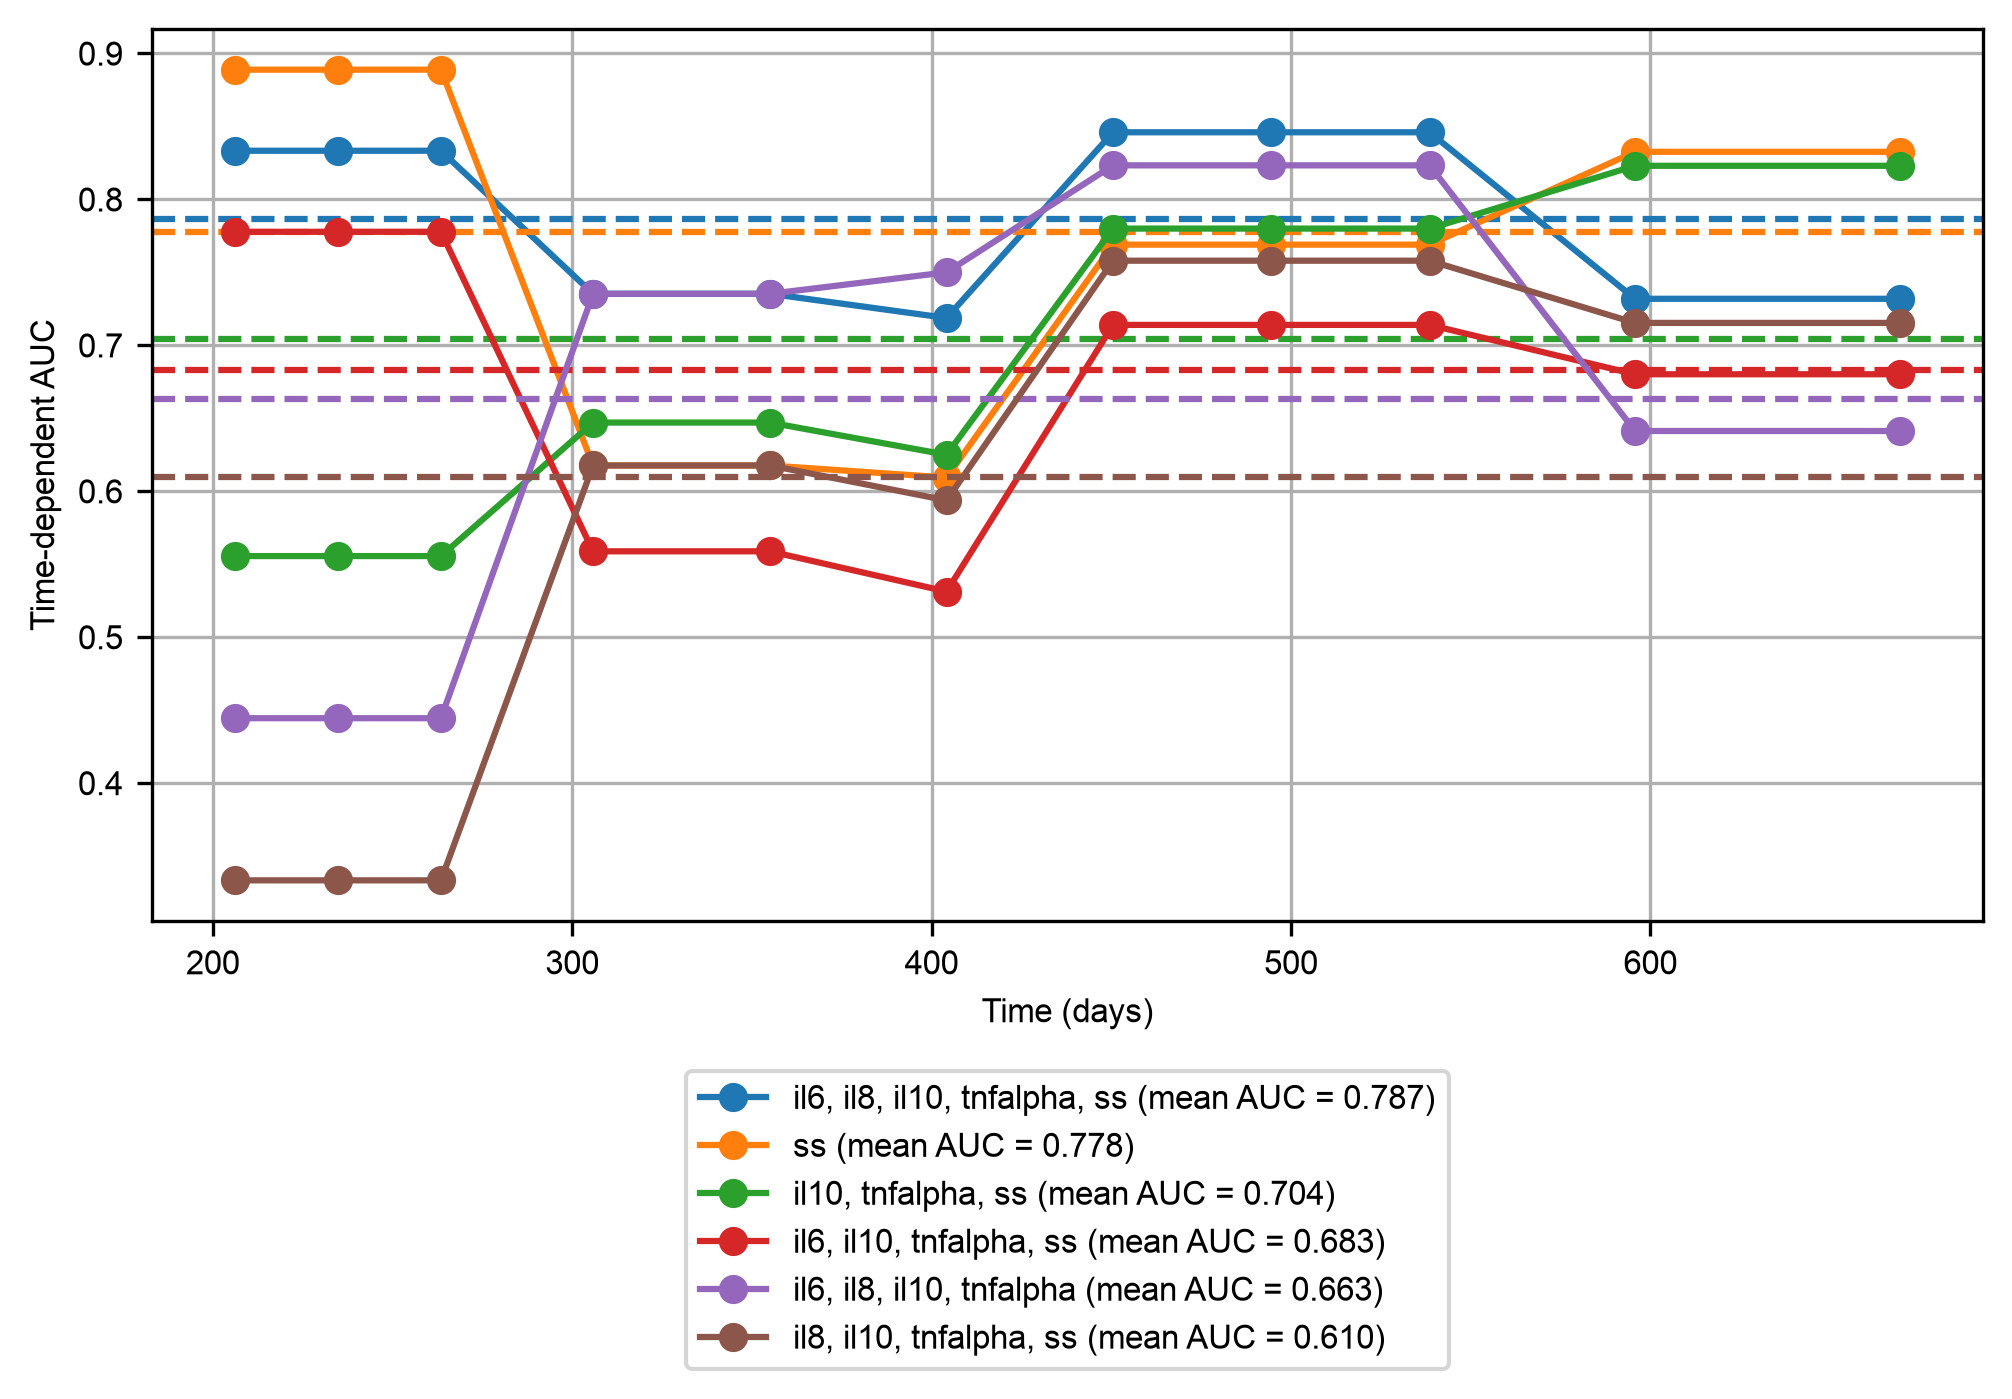

,feature_set,n_features,features,c_index,mean_auc
0,set_03,5,"il6, il8, il10, tnfalpha, ss",0.708,0.787
1,set_01,1,ss,0.775,0.778
2,set_06,3,"il10, tnfalpha, ss",0.764,0.704
3,set_04,4,"il6, il10, tnfalpha, ss",0.685,0.683
4,set_02,4,"il6, il8, il10, tnfalpha",0.562,0.663
5,set_05,4,"il8, il10, tnfalpha, ss",0.652,0.610


In [47]:
results, summary_df = run_all(
    feature_sets, cytokines_uab_df, numeric_features, y, times,
    data_dir="../data_processed", fig_dir="../figures"
)
summary_df

In [ ]:
# from itertools import combinations, chain

# items = ["ss", "il6", "il8", "il10", "tnfalpha", "hbegf", "tgfalpha"]
# rest = [item for item in items if item != "ss"]

# def all_subsets(lst):
#     return chain.from_iterable(combinations(lst, r) for r in range(1, len(lst) + 1))

# result = [("ss",) + subset for subset in all_subsets(rest)]

# feature_sets = {
#     f"set_{i:02d}": combo for i, combo in enumerate(result, start=1)
# }

# for name, combo in feature_sets.items():
#     print(name, "->", combo)

# print(f"\nTotal feature sets: {len(feature_sets)}")

In [102]:
# # Define a function to run RSF on all feature sets and plot AUC curves
# def run_all2(feature_sets, cytokines_df, numeric_features, y, times, data_dir, fig_dir, **kwargs):
#     """Run `run_rsf` for every {feature_set: cols} pair. Returns (results, summary_df)
#     and plots AUC curves only for feature sets that outperform the "ss"-only baseline."""

#     results = [
#         run_rsf(feature_set, cols, cytokines_df, numeric_features, y, times, **kwargs)
#         for feature_set, cols in feature_sets.items()
#     ]

#     summary_df = pd.DataFrame([
#         {
#             "feature_set": res["feature_set"], 
#             "n_features": len(res["features"]),
#             "features": ", ".join(res["features"]),
#             "c_index": round(res["c_index"], 3),
#             "mean_auc": round(res["mean_auc"], 3)
#         }
#         for res in results
#     ]).sort_values("mean_auc", ascending=False).reset_index(drop=True)
#     # summary_df.to_csv(f"{data_dir}/rsf_feature_sets_summary.csv", index=False)

#     # Find the reference result: the feature set containing only "ss"
#     reference = next(res for res in results if res["features"] == ["ss"])
#     reference_auc = reference["mean_auc"]

#     # Keep only results that beat the reference (reference itself included for context)
#     plot_results = [
#         res for res in results
#         if res["mean_auc"] > reference_auc or res["features"] == ["ss"]
#     ]

#     plt.figure(figsize=(10.5, 10, "cm"), dpi=300)
#     for res in plot_results:
#         line, = plt.plot(
#             times,
#             res["auc"],
#             marker="o",
#             linestyle="-",
#             label=f'{", ".join(res["features"])} (mean AUC = {res["mean_auc"]:.3f})',
#         )
#         plt.axhline(
#             res["mean_auc"],
#             color=line.get_color(),
#             linestyle="--",
#         )
#     plt.xlabel("Time (days)", fontsize=8)
#     plt.xticks(fontsize=8)
#     plt.ylabel("Time-dependent AUC", fontsize=8)
#     plt.yticks(fontsize=8)
#     # plt.title("Time-dependent AUC by feature set", fontsize=8, fontweight="bold")
#     plt.legend(loc="lower center", fontsize=8, bbox_to_anchor=(0.5, 1.02))
#     plt.grid(True)
    
#     # plt.savefig(f"{fig_dir}/time-dependent-auc_features-comparison_rsf-model_within2yrs.pdf", dpi=300, bbox_inches="tight", facecolor="white")
    
#     plt.show()
    
#     return results, summary_df

In [ ]:
# results, summary_df = run_all2(
#     feature_sets, cytokines_llu_df, numeric_features, y, times,
#     data_dir="../data_processed", fig_dir="../figures"
# )
# summary_df

## 3. Hyperparameter tuning of the RSF model on the best subset of features

In [46]:
# Best subset of features for RSF model
selected_features = numeric_features.intersection(feature_sets["set_06"])
print(f"Selected features for ML model: {selected_features}")

# `selected_features` is a pandas Index; convert to list before adding "cohort"
feature_cols = selected_features.tolist() + ["cohort"]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    cytokines_df[feature_cols],
    y,
    test_size=0.2,
    random_state=2024,
    stratify=y["event"],
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Preprcessing
# Fit one scaler per cohort on the training set, store them explicitly
cohort_scalers = {}
for cohort, group in X_train.groupby("cohort"):
    sc = StandardScaler()
    sc.fit(group[selected_features])
    cohort_scalers[cohort] = sc

def apply_cohort_scaling(X, scalers, feature_cols):
    parts = []
    for cohort, group in X.groupby("cohort"):
        transformed = scalers[cohort].transform(group[feature_cols])
        parts.append(pd.DataFrame(transformed, columns=feature_cols, index=group.index))
    return pd.concat(parts).loc[X.index]

X_train_transformed = apply_cohort_scaling(X_train, cohort_scalers, selected_features)
X_test_transformed = apply_cohort_scaling(X_test, cohort_scalers, selected_features)

# Random Survival Forest (RSF) model
rsf = RandomSurvivalForest(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=30,
    min_samples_split=2,
    max_features="sqrt",
    random_state=2026
)
rsf.fit(X_train_transformed, y_train)

c_index = rsf.score(X_test_transformed, y_test)
print(f"C-index: {round(c_index, 3)}")

rsf_risk_scores = rsf.predict(X_test_transformed)
rsf_auc, rsf_mean_auc = cumulative_dynamic_auc(y_train, y_test, rsf_risk_scores, times)
print(f"Mean AUC: {rsf_mean_auc:.3f}")

Selected features for ML model: Index(['il10', 'tnfalpha', 'ss'], dtype='object')
Training set size: 169 samples
Test set size: 43 samples
C-index: 0.766
Mean AUC: 0.853


RSF params:
- n_estimators: 200
- max_depth: None
- min_samples_leaf: 30
- min_samples_split: 2
- max_features: "sqrt"
- the rests are default values

In [48]:
# Save the RSF model and related artifacts for future use
artifact = {
    "model": rsf,
    "cohort_scalers": cohort_scalers,
    "selected_features": list(selected_features),
    "X_train": X_train_transformed,
    "X_test": X_test_transformed,
    "y_train": y_train,
    "y_test": y_test,
    "times": times,
    "c_index": c_index,
    "mean_auc": rsf_mean_auc,
    "sksurv_version": __import__("sksurv").__version__,
    "sklearn_version": __import__("sklearn").__version__,
}

joblib.dump(artifact, "../data_processed/rsf_bundle.joblib")

['../data_processed/rsf_bundle.joblib']